## BreakPoints

When using the `Human-in-the-loop`, we want to see the output states in between as the flow is still running, for this we use the breakpoints

### Goals: 
1. `Approval` - Can Interrupt our agent, surface state to the user and allow the user ot accept an action.
2. `Debugging` - We can rewind the graph, to reproduce or avoide the issues. 
3. `Editing` - You can modify the state.

There are several ways to get and update the agent state to support various `human-in-the-loop` workflows.

[Breakpoints](https://docs.langchain.com/oss/python/langgraph/interrupts#debugging-with-interrupts)


In [2]:
from warnings import filterwarnings
filterwarnings('ignore')

import os
from dotenv import load_dotenv
from langchain_aws import ChatBedrockConverse
load_dotenv()

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ["LANGCHAIN_TRACING_V2"] = "true" # Enable LangSmith tracing
os.environ['LANGSMITH_PROJECT'] = 'LangGraphTraining' 

model = ChatBedrockConverse(model= "us.anthropic.claude-sonnet-4-6",)

In [6]:
from langgraph.graph import START, END, StateGraph, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import HumanMessage, SystemMessage

If we want to get the user permission to run/use the tools, we use `interrupt_before=['tools']` wehre tools are out nodes.


In [12]:
def multiply(a: int, b: int) -> int:
    '''Multipy the 2 given integers'''
    return a * b
def add(a: int, b: int) -> int:
    '''Adds the 2 given integers'''
    return a + b
def divide(a: int, b: int) -> float:
    '''Divides the 2 given integers'''
    if b == 0:
        raise ValueError("Cannot divide by zero.")
    return a / b

tools = [add, multiply, divide]
llm_with_tools = model.bind_tools(tools)

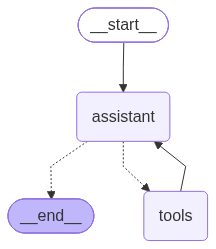

In [17]:
# System Message
system_message = SystemMessage('You are a helpful assistant tasked with performing arithmatic on set of inputs using the tools')

def assistant(state: MessagesState):
    return {'messages': [llm_with_tools.invoke([system_message] + state['messages'])]}

# Graph
builder = StateGraph(MessagesState)
builder.add_node('assistant', assistant)
builder.add_node('tools', ToolNode(tools))

builder.add_edge(START, 'assistant')
builder.add_conditional_edges('assistant', tools_condition)
builder.add_edge('tools', 'assistant')

graph_without_interupt = builder.compile(checkpointer = MemorySaver())
graph_without_interupt

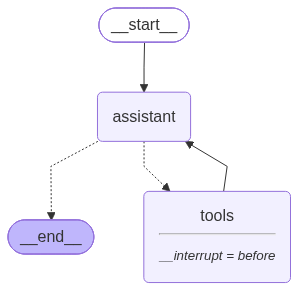

In [18]:
interupt_graph = builder.compile(checkpointer = MemorySaver(), interrupt_before=['tools'])
interupt_graph

In [27]:
initial_input = {'messages': HumanMessage('Multiply 2 and 3')}
thread_without_interupt = {'configurable': {'thread_id': 'without_4'}}
thread_interupt = {'configurable': {'thread_id': 'inter_1'}}

for event in graph_without_interupt.stream(initial_input, thread_without_interupt, stream_mode = 'values'):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================

[{'type': 'text', 'text': "I'll multiply 2 and 3 right away!"}, {'type': 'tool_use', 'name': 'multiply', 'input': {'a': 2, 'b': 3}, 'id': 'tooluse_dm1t9XBj3Gv9vYYasYJjjG'}]
Tool Calls:
  multiply (tooluse_dm1t9XBj3Gv9vYYasYJjjG)
 Call ID: tooluse_dm1t9XBj3Gv9vYYasYJjjG
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying **2** and **3** is **6**! 🎉


In [28]:
for event in interupt_graph.stream(initial_input, thread_interupt, stream_mode = 'values'):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================

[{'type': 'text', 'text': "I'll multiply 2 and 3 right away!"}, {'type': 'tool_use', 'name': 'multiply', 'input': {'a': 2, 'b': 3}, 'id': 'tooluse_dgQtlmVKTsduVxqo0Pe6ia'}]
Tool Calls:
  multiply (tooluse_dgQtlmVKTsduVxqo0Pe6ia)
 Call ID: tooluse_dgQtlmVKTsduVxqo0Pe6ia
  Args:
    a: 2
    b: 3


When we are using the interupt, the graph is watiting for the model to varify the before doing the tool call.
Which can be fetched, and prompted to the user screen and can get the user validation

In [32]:
state = interupt_graph.get_state(thread_interupt)
state.values

{'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='c83a8796-d1e3-42a2-9d22-42c45f546474'),
  AIMessage(content=[{'type': 'text', 'text': "I'll multiply 2 and 3 right away!"}, {'type': 'tool_use', 'name': 'multiply', 'input': {'a': 2, 'b': 3}, 'id': 'tooluse_dgQtlmVKTsduVxqo0Pe6ia'}], additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': 'e1084fca-5907-4cc6-824c-417d25da5a0a', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Thu, 13 Aug 2026 06:51:32 GMT', 'content-type': 'application/json', 'content-length': '465', 'connection': 'keep-alive', 'x-amzn-requestid': 'e1084fca-5907-4cc6-824c-417d25da5a0a'}, 'RetryAttempts': 0}, 'stopReason': 'tool_use', 'metrics': {'latencyMs': [1497]}, 'model_provider': 'bedrock_converse', 'model_name': 'us.anthropic.claude-sonnet-4-6'}, id='lc_run--019ff9e3-e8b4-7052-a8ef-ad8c9301b5a5-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'tooluse_dgQtlmVKTsduVxqo0Pe6ia'

In [33]:
state.next

('tools',)

The next state of the node is the tools node, but there is an interuption before that.

To invoke the next node, without passing any input, we can use `None` and it shall continue from the last state checkpoint

In [34]:
for event in interupt_graph.stream(None, thread_interupt, stream_mode = 'values'):
    event['messages'][-1].pretty_print()

================================== Ai Message ==================================

[{'type': 'text', 'text': "I'll multiply 2 and 3 right away!"}, {'type': 'tool_use', 'name': 'multiply', 'input': {'a': 2, 'b': 3}, 'id': 'tooluse_dgQtlmVKTsduVxqo0Pe6ia'}]
Tool Calls:
  multiply (tooluse_dgQtlmVKTsduVxqo0Pe6ia)
 Call ID: tooluse_dgQtlmVKTsduVxqo0Pe6ia
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying **2** and **3** is **6**! 🎉


Comipling all at once.

In [37]:
initial_input = {'messages': HumanMessage('Add 2 and 3')}
thread_interupt = {'configurable': {'thread_id': 'inter_3'}}

for event in interupt_graph.stream(initial_input, thread_interupt, stream_mode='values'):
    event['messages'][-1].pretty_print()

# Getting user feedback
user_approval = input('Do you wnat the tool to continue?')
# check for the approval
if user_approval.lower() in ['yes', 'y']:
    for event in interupt_graph.stream(None, thread_interupt, stream_mode='values'):
        event['messages'][-1].pretty_print()
else:
    print('Operation cancelled')

================================ Human Message =================================

Add 2 and 3
================================== Ai Message ==================================

[{'type': 'text', 'text': "I'll add 2 and 3 right away!"}, {'type': 'tool_use', 'name': 'add', 'input': {'a': 2, 'b': 3}, 'id': 'tooluse_Unm27NuQCGWHNL8U7LUnKw'}]
Tool Calls:
  add (tooluse_Unm27NuQCGWHNL8U7LUnKw)
 Call ID: tooluse_Unm27NuQCGWHNL8U7LUnKw
  Args:
    a: 2
    b: 3
================================== Ai Message ==================================

[{'type': 'text', 'text': "I'll add 2 and 3 right away!"}, {'type': 'tool_use', 'name': 'add', 'input': {'a': 2, 'b': 3}, 'id': 'tooluse_Unm27NuQCGWHNL8U7LUnKw'}]
Tool Calls:
  add (tooluse_Unm27NuQCGWHNL8U7LUnKw)
 Call ID: tooluse_Unm27NuQCGWHNL8U7LUnKw
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: add

5
================================== Ai Message ==================================

The 

We can also use the langgraph client API, for the task - Not using 